<a href="https://colab.research.google.com/github/Samantha088/NN_ac/blob/main/Coffee_Shop_Sales_Analysis_and_Regression_Model_on_Coffee_Orders_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Coffee Shop Sales Analysis and Regression Modeling on Coffee Orders Dataset***

# **Step 1: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


# **Step 2: Load Dataset**

In [ ]:
# Upload your CSV file to Colab
from google.colab import files
uploaded = files.upload()

# Load into pandas
for filename in uploaded.keys():
    df = pd.read_csv(filename)

# Preview dataset
df.head()


Saving coffee shop records.csv to coffee shop records.csv


,date,datetime,cash_type,money,coffee_name
0,08-02-2025,08-02-2025 14:26,cash,15,Tea
1,08-02-2025,08-02-2025 14:28,cash,15,Tea
2,08-02-2025,08-02-2025 14:33,card,20,Espresso
3,08-02-2025,08-02-2025 15:51,card,30,Chocolate with coffee
4,08-02-2025,08-02-2025 16:35,cash,27,Chocolate with milk


# **Step 3: Explore Dataset**

In [ ]:
# Check columns, data types, missing values
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         262 non-null    object
 1   datetime     262 non-null    object
 2   cash_type    262 non-null    object
 3   money        262 non-null    int64 
 4   coffee_name  262 non-null    object
dtypes: int64(1), object(4)
memory usage: 10.4+ KB
None
           money
count  262.00000
mean    26.29771
std      4.25021
min     15.00000
25%     25.00000
50%     27.00000
75%     29.00000
max     33.00000
date           0
datetime       0
cash_type      0
money          0
coffee_name    0
dtype: int64


# **Step 4: Data Preprocessing**

In [ ]:
# Convert 'date' and 'datetime' to datetime objects
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M')

# Encode categorical variables (cash_type, coffee_name)
le_cash = LabelEncoder()
df['cash_type_encoded'] = le_cash.fit_transform(df['cash_type'])

le_coffee = LabelEncoder()
df['coffee_name_encoded'] = le_coffee.fit_transform(df['coffee_name'])

# Final feature set
X = df[['cash_type_encoded', 'coffee_name_encoded']]
y = df['money']


# **Step 5: Split into Train and Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (209, 2)
Test shape: (53, 2)


# **Step 6: Train Linear Regression Model**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


# **Step 7: Evaluate Model**

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: -0.0789
MAE: 3.43
RMSE: 4.42


# **Step 8: Visualizations**

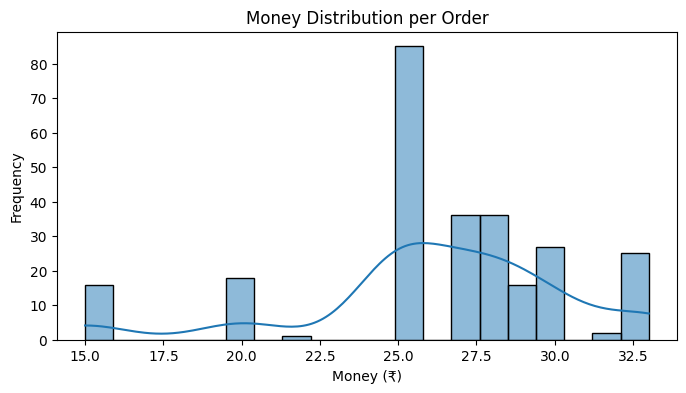

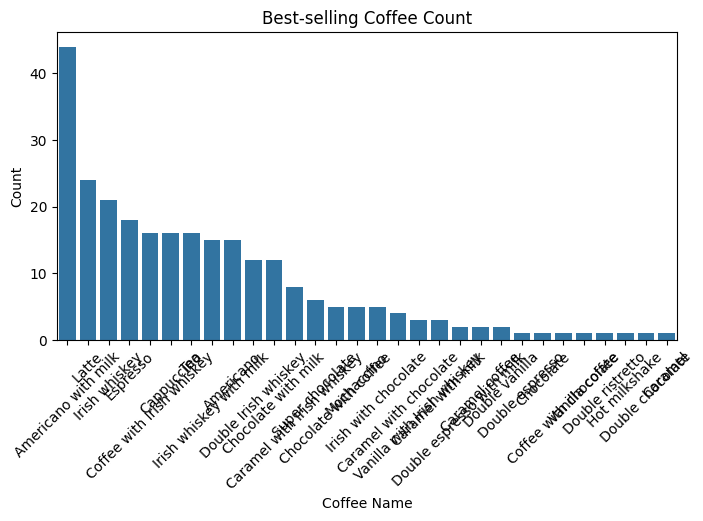

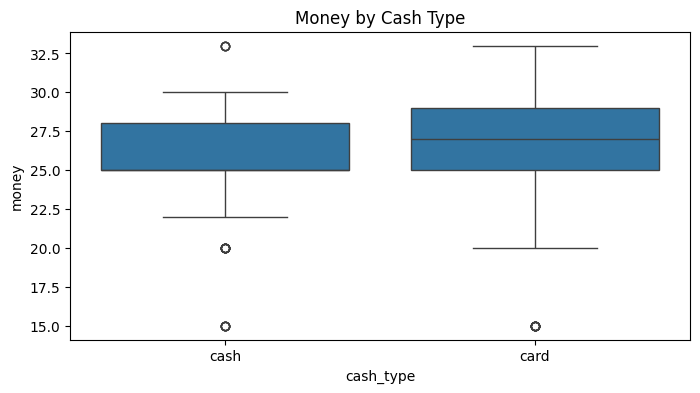

In [ ]:
# 1. Sales distribution
plt.figure(figsize=(8,4))
sns.histplot(df['money'], bins=20, kde=True)
plt.title("Money Distribution per Order")
plt.xlabel("Money (₹)")
plt.ylabel("Frequency")
plt.show()

# 2. Best-selling coffee
plt.figure(figsize=(8,4))
sns.countplot(x='coffee_name', data=df, order=df['coffee_name'].value_counts().index)
plt.title("Best-selling Coffee Count")
plt.xlabel("Coffee Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 3. Money by cash type
plt.figure(figsize=(8,4))
sns.boxplot(x='cash_type', y='money', data=df)
plt.title("Money by Cash Type")
plt.show()


# **Step 9: Predict New Orders**

In [ ]:
# Example: Cash, Latte
new_order = pd.DataFrame({
    'cash_type_encoded': [le_cash.transform(['cash'])[0]],
    'coffee_name_encoded': [le_coffee.transform(['Latte'])[0]] # Assuming Latte is consistent in casing from training data
})

predicted_money = model.predict(new_order)
print("Predicted money for new order:", predicted_money[0])

Predicted money for new order: 24.30633211798598
